<a href="https://colab.research.google.com/github/nikki-nooka/15-09-2025/blob/main/Duality_AI_Drone_Detection_Nikshith.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛩️ Sim-to-Real EO Drone Detection using Duality AI Falcon and YOLO11n

### AI/ML Track — Elite Coders Summer of Code

**Developed by:** Nooka Nikshith  
**Task:** Drone and Bird Object Detection in Electro-Optical Imagery  
**Simulation Platform:** Duality AI Falcon  
**Detection Model:** YOLO11n  

---

## Project Overview

Small aerial objects such as unmanned aerial vehicles (UAVs) are challenging to detect in Electro-Optical (EO) imagery because their visual appearance varies significantly with distance, viewing angle, background, illumination, and the number of pixels occupied by the target.

A particularly important challenge is distinguishing drones from birds. At long distances, both objects may occupy only a small number of pixels and can exhibit visually similar silhouettes.

This project develops a lightweight two-class object-detection system capable of detecting:

- **Class 0 — Drone**
- **Class 1 — Bird**

The project follows a simulation-driven machine-learning workflow:

**Duality AI Falcon → Synthetic Data Generation → Dataset Preparation → Dataset Combination → YOLO11n Training → Validation → Qualitative Analysis → Final Model**

The final model achieved an **mAP@0.50 of 90.53%** on the held-out validation dataset.

# 1. Problem Statement

Reliable drone detection is an important computer-vision problem in Counter-Unmanned Aircraft System (C-UAS) applications.

EO-based detection presents several challenges:

1. **Small object size** — distant drones may occupy very few pixels.
2. **Background complexity** — sky, vegetation, terrain, and infrastructure can introduce visual clutter.
3. **Bird confusion** — birds may resemble drones at long range.
4. **Scale variation** — the apparent size of a drone changes significantly with distance.
5. **Limited labeled data** — collecting diverse real-world drone imagery can be expensive and difficult.

To address these challenges, this project uses synthetic data generated through the Duality AI Falcon workflow and trains a lightweight YOLO11n object detector.

## Objective

The objective is to develop and evaluate a model capable of:

- Detecting drones in EO imagery.
- Distinguishing drones from birds.
- Handling variations in target scale and background.
- Maintaining a lightweight model architecture suitable for efficient inference.

# 2. End-to-End Technical Workflow

The complete project pipeline consists of the following stages:

### Stage 1 — Simulation Configuration
The Rural C-UAS simulation scenario was configured in Duality AI Falcon.

### Stage 2 — Synthetic Data Generation
Synthetic EO imagery and object annotations were generated from the simulation environment.

### Stage 3 — Target Distribution Configuration
A custom IEEE pixels-on-target distribution was incorporated to control the apparent scale distribution of simulated targets.

### Stage 4 — Multi-Class Dataset Preparation
The dataset was configured for two classes:

- Drone
- Bird

### Stage 5 — Dataset Integration
The generated synthetic data was combined with the available EO dataset.

### Stage 6 — YOLO Dataset Preparation
Images and annotations were organized into YOLO-compatible training and validation directories.

### Stage 7 — Model Training
A YOLO11n object detector was trained using the combined dataset.

### Stage 8 — Model Validation
The best trained checkpoint was evaluated on the held-out validation dataset.

### Stage 9 — Qualitative Analysis
Ground-truth annotations and model predictions were visually compared.

### Stage 10 — Final Model Selection
The selected model was preserved as `final_eo_model.pt`.

# 3. Synthetic Data Generation using Duality AI Falcon

Synthetic data was generated using the Duality AI Falcon simulation workflow.

The simulation-based approach provides several advantages:

- Automated annotation generation.
- Controlled environmental variation.
- Repeatable experiments.
- Variation in object position and apparent scale.
- Ability to introduce difficult airborne confusers.
- Reduced dependence on manually annotated real-world imagery.

## Rural C-UAS Scenario

The project used the `Hackathon_RuralCUAS` simulation environment.

The scenario included aerial objects and environmental elements relevant to EO-based drone detection.

## Simulation Configuration

The synthetic-data generation configuration included the following parameters:

| Parameter | Value |
|---|---:|
| Bird Enabled | 1 |
| Drone Bin Size | 40,000 |
| Drone Data Distribution Mode | 2 |
| Drone Distribution | `custom_distributions/ieee_pixels_on_target.npy` |
| Film Grain Intensity | 0.5 |
| Film Grain Texel Size | 0.2 |
| Fixed Base Random Transforms | 1 |
| Manned Aircraft Enabled | 0 |
| Sample Size | 500 |

## Custom Pixels-on-Target Distribution

A custom IEEE pixels-on-target distribution was incorporated into the simulation configuration.

Pixels on target is an important factor in EO object detection because it directly influences the amount of visual information available to the detector.

By varying the apparent target size, the synthetic dataset can expose the model to objects at different effective distances and scales.

# 4. Dataset Engineering

## Generated Synthetic Dataset

The Falcon-generated dataset was exported with image and annotation data.

During dataset inspection, the annotation files were found to contain two object classes:

- `0` — Drone
- `1` — Bird

The dataset configuration was therefore updated to correctly represent both classes.

## YOLO Dataset Configuration

The final dataset configuration uses:

    nc: 2

    names:
      0: drone
      1: bird

## Dataset Integration

The newly generated synthetic dataset was combined with the available EO dataset to create the final training dataset:

    combined_eo_v2

## Final Dataset Statistics

| Split | Images | Label Files |
|---|---:|---:|
| Training | 1,521 | 1,521 |
| Validation | 441 | 441 |
| **Total** | **1,962** | **1,962** |

The final dataset maintains a one-to-one correspondence between image files and YOLO annotation files.

In [27]:
from pathlib import Path
from collections import Counter

DATASET_ROOT = Path(
    "/content/duality_dataset/datasets/combined_eo_v2"
)

class_counts = Counter()
invalid_lines = 0

for split in ["train", "val"]:
    label_dir = DATASET_ROOT / split / "labels"

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 5:
                    class_id = int(float(parts[0]))
                    class_counts[class_id] += 1
                else:
                    invalid_lines += 1

print("========== ANNOTATION ANALYSIS ==========")
print("Drone instances :", class_counts[0])
print("Bird instances  :", class_counts[1])
print("Total instances :", sum(class_counts.values()))
print("Invalid lines   :", invalid_lines)
print("=========================================")

========== ANNOTATION ANALYSIS ==========
Drone instances : 1962
Bird instances  : 1458
Total instances : 3420
Invalid lines   : 0


# 5. Model Selection and Training Strategy

## Why YOLO11n?

YOLO11n was selected as the final architecture because the project required a balance between detection performance and computational efficiency.

The model provides:

- A compact architecture.
- Low parameter count.
- Efficient inference.
- Support for real-time-oriented deployment scenarios.
- Strong performance for object detection.

## Model Characteristics

| Property | Value |
|---|---|
| Architecture | YOLO11n |
| Parameters | 2,582,542 |
| Computational Complexity | 6.3 GFLOPs |
| Number of Classes | 2 |
| Final Model Size | 5.19 MB |

## Training Strategy

An initial heavier training configuration was explored using a larger YOLO variant and higher computational settings.

However, local training efficiency was an important practical constraint. A lightweight YOLO11n configuration was therefore selected to achieve a better balance between:

- Training time
- Computational cost
- Model size
- Detection performance

The best-performing checkpoint was preserved as:

    final_eo_model.pt

# 6. Experimental Environment

## Original Development Environment

The model-development workflow was performed using:

- Apple Silicon M5
- PyTorch MPS acceleration
- Ultralytics YOLO
- Python 3.9

## Independent Validation Environment

The final trained model was subsequently loaded and independently evaluated in Google Colab using:

- NVIDIA Tesla T4 GPU
- CUDA-enabled PyTorch
- Ultralytics 8.4.95

This independent validation step verifies that the saved model artifact can be successfully loaded and evaluated outside the original local development environment.

# 7. Quantitative Evaluation

The final YOLO11n model was evaluated on the held-out validation split containing **441 images**.

## Final Results

| Metric | Score | Percentage |
|---|---:|---:|
| Precision | 0.9445 | 94.45% |
| Recall | 0.8558 | 85.58% |
| mAP@0.50 | 0.9053 | 90.53% |
| mAP@0.50–0.95 | 0.6473 | 64.73% |

## Interpretation

### Precision — 94.45%

The high precision indicates that the majority of detections produced by the model corresponded to valid annotated objects.

### Recall — 85.58%

The model detected a large proportion of the ground-truth objects. The remaining recall gap indicates that some difficult targets were missed.

Potential causes include:

- Extremely small apparent object size.
- Partial visibility.
- Low target-background contrast.
- Difficult viewing conditions.

### mAP@0.50 — 90.53%

The model achieved strong detection performance at an IoU threshold of 0.50.

### mAP@0.50–0.95 — 64.73%

The stricter COCO-style mAP score reflects performance across multiple IoU thresholds. The difference between mAP@0.50 and mAP@0.50–0.95 indicates that precise bounding-box localization remains more challenging than general object detection.

In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.7 MB/s eta 0:00:00


In [3]:
import ultralytics
import torch

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.95
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if (
            "combined_eo_v2" in file.lower()
            or "final_eo_model" in file.lower()
            or file.lower().endswith(".zip")
            or file.lower().endswith(".pt")
        ):
            print(os.path.join(root, file))

/content/drive/MyDrive/DUALITY-AI-HACKATHON/combined_eo_v2.zip
/content/drive/MyDrive/DUALITY-AI-HACKATHON/models/yolo11n_ieee_best.pt
/content/drive/MyDrive/DUALITY-AI-HACKATHON/models/final_eo_model.pt
/content/drive/MyDrive/DUALITY-AI-HACKATHON/models/baseline/combined_eo_best.pt


In [6]:
import os
import zipfile

ZIP_PATH = "/content/drive/MyDrive/DUALITY-AI-HACKATHON/combined_eo_v2.zip"
EXTRACT_PATH = "/content/duality_dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [7]:
!find /content/duality_dataset -maxdepth 4 -type d | head -30

/content/duality_dataset
/content/duality_dataset/datasets
/content/duality_dataset/datasets/combined_eo_v2
/content/duality_dataset/datasets/combined_eo_v2/val
/content/duality_dataset/datasets/combined_eo_v2/val/labels
/content/duality_dataset/datasets/combined_eo_v2/val/images
/content/duality_dataset/datasets/combined_eo_v2/train
/content/duality_dataset/datasets/combined_eo_v2/train/labels
/content/duality_dataset/datasets/combined_eo_v2/train/images


In [8]:
from pathlib import Path

DATASET_ROOT = Path(
    "/content/duality_dataset/datasets/combined_eo_v2"
)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

train_images = [
    f for f in (DATASET_ROOT / "train/images").iterdir()
    if f.is_file() and f.suffix.lower() in image_extensions
]

train_labels = list(
    (DATASET_ROOT / "train/labels").glob("*.txt")
)

val_images = [
    f for f in (DATASET_ROOT / "val/images").iterdir()
    if f.is_file() and f.suffix.lower() in image_extensions
]

val_labels = list(
    (DATASET_ROOT / "val/labels").glob("*.txt")
)

print("========== DATASET VERIFICATION ==========")
print(f"Training images     : {len(train_images)}")
print(f"Training labels     : {len(train_labels)}")
print(f"Validation images   : {len(val_images)}")
print(f"Validation labels   : {len(val_labels)}")
print(f"Total images        : {len(train_images) + len(val_images)}")
print("==========================================")

========== DATASET VERIFICATION ==========
Training images     : 1521
Training labels     : 1521
Validation images   : 441
Validation labels   : 441
Total images        : 1962


In [9]:
import os

MODEL_PATH = "/content/drive/MyDrive/DUALITY-AI-HACKATHON/models/final_eo_model.pt"

if os.path.exists(MODEL_PATH):
    size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)

    print("✅ FINAL MODEL FOUND")
    print("Model path:", MODEL_PATH)
    print(f"Model size: {size_mb:.2f} MB")
else:
    print("❌ Model not found")

✅ FINAL MODEL FOUND
Model path: /content/drive/MyDrive/DUALITY-AI-HACKATHON/models/final_eo_model.pt
Model size: 5.19 MB


In [10]:
from pathlib import Path

DATASET_ROOT = Path(
    "/content/duality_dataset/datasets/combined_eo_v2"
)

YAML_PATH = DATASET_ROOT / "data_colab.yaml"

yaml_content = f"""
path: {DATASET_ROOT}
train: train/images
val: val/images

nc: 2
names:
  0: drone
  1: bird
"""

YAML_PATH.write_text(yaml_content.strip() + "\n")

print("✅ Colab dataset configuration created")
print("YAML path:", YAML_PATH)
print("\n========== data_colab.yaml ==========")
print(YAML_PATH.read_text())

✅ Colab dataset configuration created
YAML path: /content/duality_dataset/datasets/combined_eo_v2/data_colab.yaml

========== data_colab.yaml ==========
path: /content/duality_dataset/datasets/combined_eo_v2
train: train/images
val: val/images

nc: 2
names:
  0: drone
  1: bird



In [11]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/DUALITY-AI-HACKATHON/models/final_eo_model.pt"

model = YOLO(MODEL_PATH)

print("✅ Final trained YOLO model loaded successfully!")
print("Model classes:", model.names)

✅ Final trained YOLO model loaded successfully!
Model classes: {0: 'drone', 1: 'bird'}


In [12]:
from pathlib import Path

YAML_PATH = Path(
    "/content/duality_dataset/datasets/combined_eo_v2/data_colab.yaml"
)

metrics = model.val(
    data=str(YAML_PATH),
    imgsz=512,
    batch=16,
    device=0,
    plots=True,
    project="/content/duality_results",
    name="final_validation"
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4683.3±1315.0 MB/s, size: 962.1 KB)
val: Scanning /content/duality_dataset/datasets/combined_eo_v2/val/labels... 441 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 441/441 408.7it/s 1.1s
val: New cache created: /content/duality_dataset/datasets/combined_eo_v2/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 5.1it/s 5.5s
                   all        441        766      0.945      0.856      0.905      0.647
                 drone        441        441      0.949      0.841      0.913       0.66
                  bird        325        325       0.94      0.871      0.897      0.635
Speed: 1.1ms preprocess, 2.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/

In [13]:
print("\n" + "=" * 55)
print("       FINAL YOLO11n VALIDATION RESULTS")
print("=" * 55)

print(f"Precision       : {metrics.box.mp:.4f}")
print(f"Recall          : {metrics.box.mr:.4f}")
print(f"mAP@0.50        : {metrics.box.map50:.4f}")
print(f"mAP@0.50-0.95   : {metrics.box.map:.4f}")

print("=" * 55)


       FINAL YOLO11n VALIDATION RESULTS
Precision       : 0.9445
Recall          : 0.8558
mAP@0.50        : 0.9053
mAP@0.50-0.95   : 0.6473


In [14]:
import shutil
from pathlib import Path

SOURCE = Path("/content/duality_results/final_validation")
DESTINATION = Path(
    "/content/drive/MyDrive/DUALITY-AI-HACKATHON/final_validation_results"
)

if DESTINATION.exists():
    shutil.rmtree(DESTINATION)

shutil.copytree(SOURCE, DESTINATION)

print("✅ Validation results saved permanently to Google Drive")
print("Saved at:", DESTINATION)

✅ Validation results saved permanently to Google Drive
Saved at: /content/drive/MyDrive/DUALITY-AI-HACKATHON/final_validation_results


In [15]:
import os

RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "DUALITY-AI-HACKATHON/final_validation_results"
)

for file in sorted(os.listdir(RESULTS_PATH)):
    print(file)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg


In [17]:
import shutil
from pathlib import Path

SOURCE = Path("/content/duality_results/final_validation")
DESTINATION = Path(
    "/content/drive/MyDrive/DUALITY-AI-HACKATHON/final_validation_results"
)

if DESTINATION.exists():
    shutil.rmtree(DESTINATION)

shutil.copytree(SOURCE, DESTINATION)

print("✅ Validation results saved permanently to Google Drive")
print("Saved at:", DESTINATION)

✅ Validation results saved permanently to Google Drive
Saved at: /content/drive/MyDrive/DUALITY-AI-HACKATHON/final_validation_results


In [18]:
import os

RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "DUALITY-AI-HACKATHON/final_validation_results"
)

for file in sorted(os.listdir(RESULTS_PATH)):
    print(file)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg



===== confusion_matrix_normalized.png =====


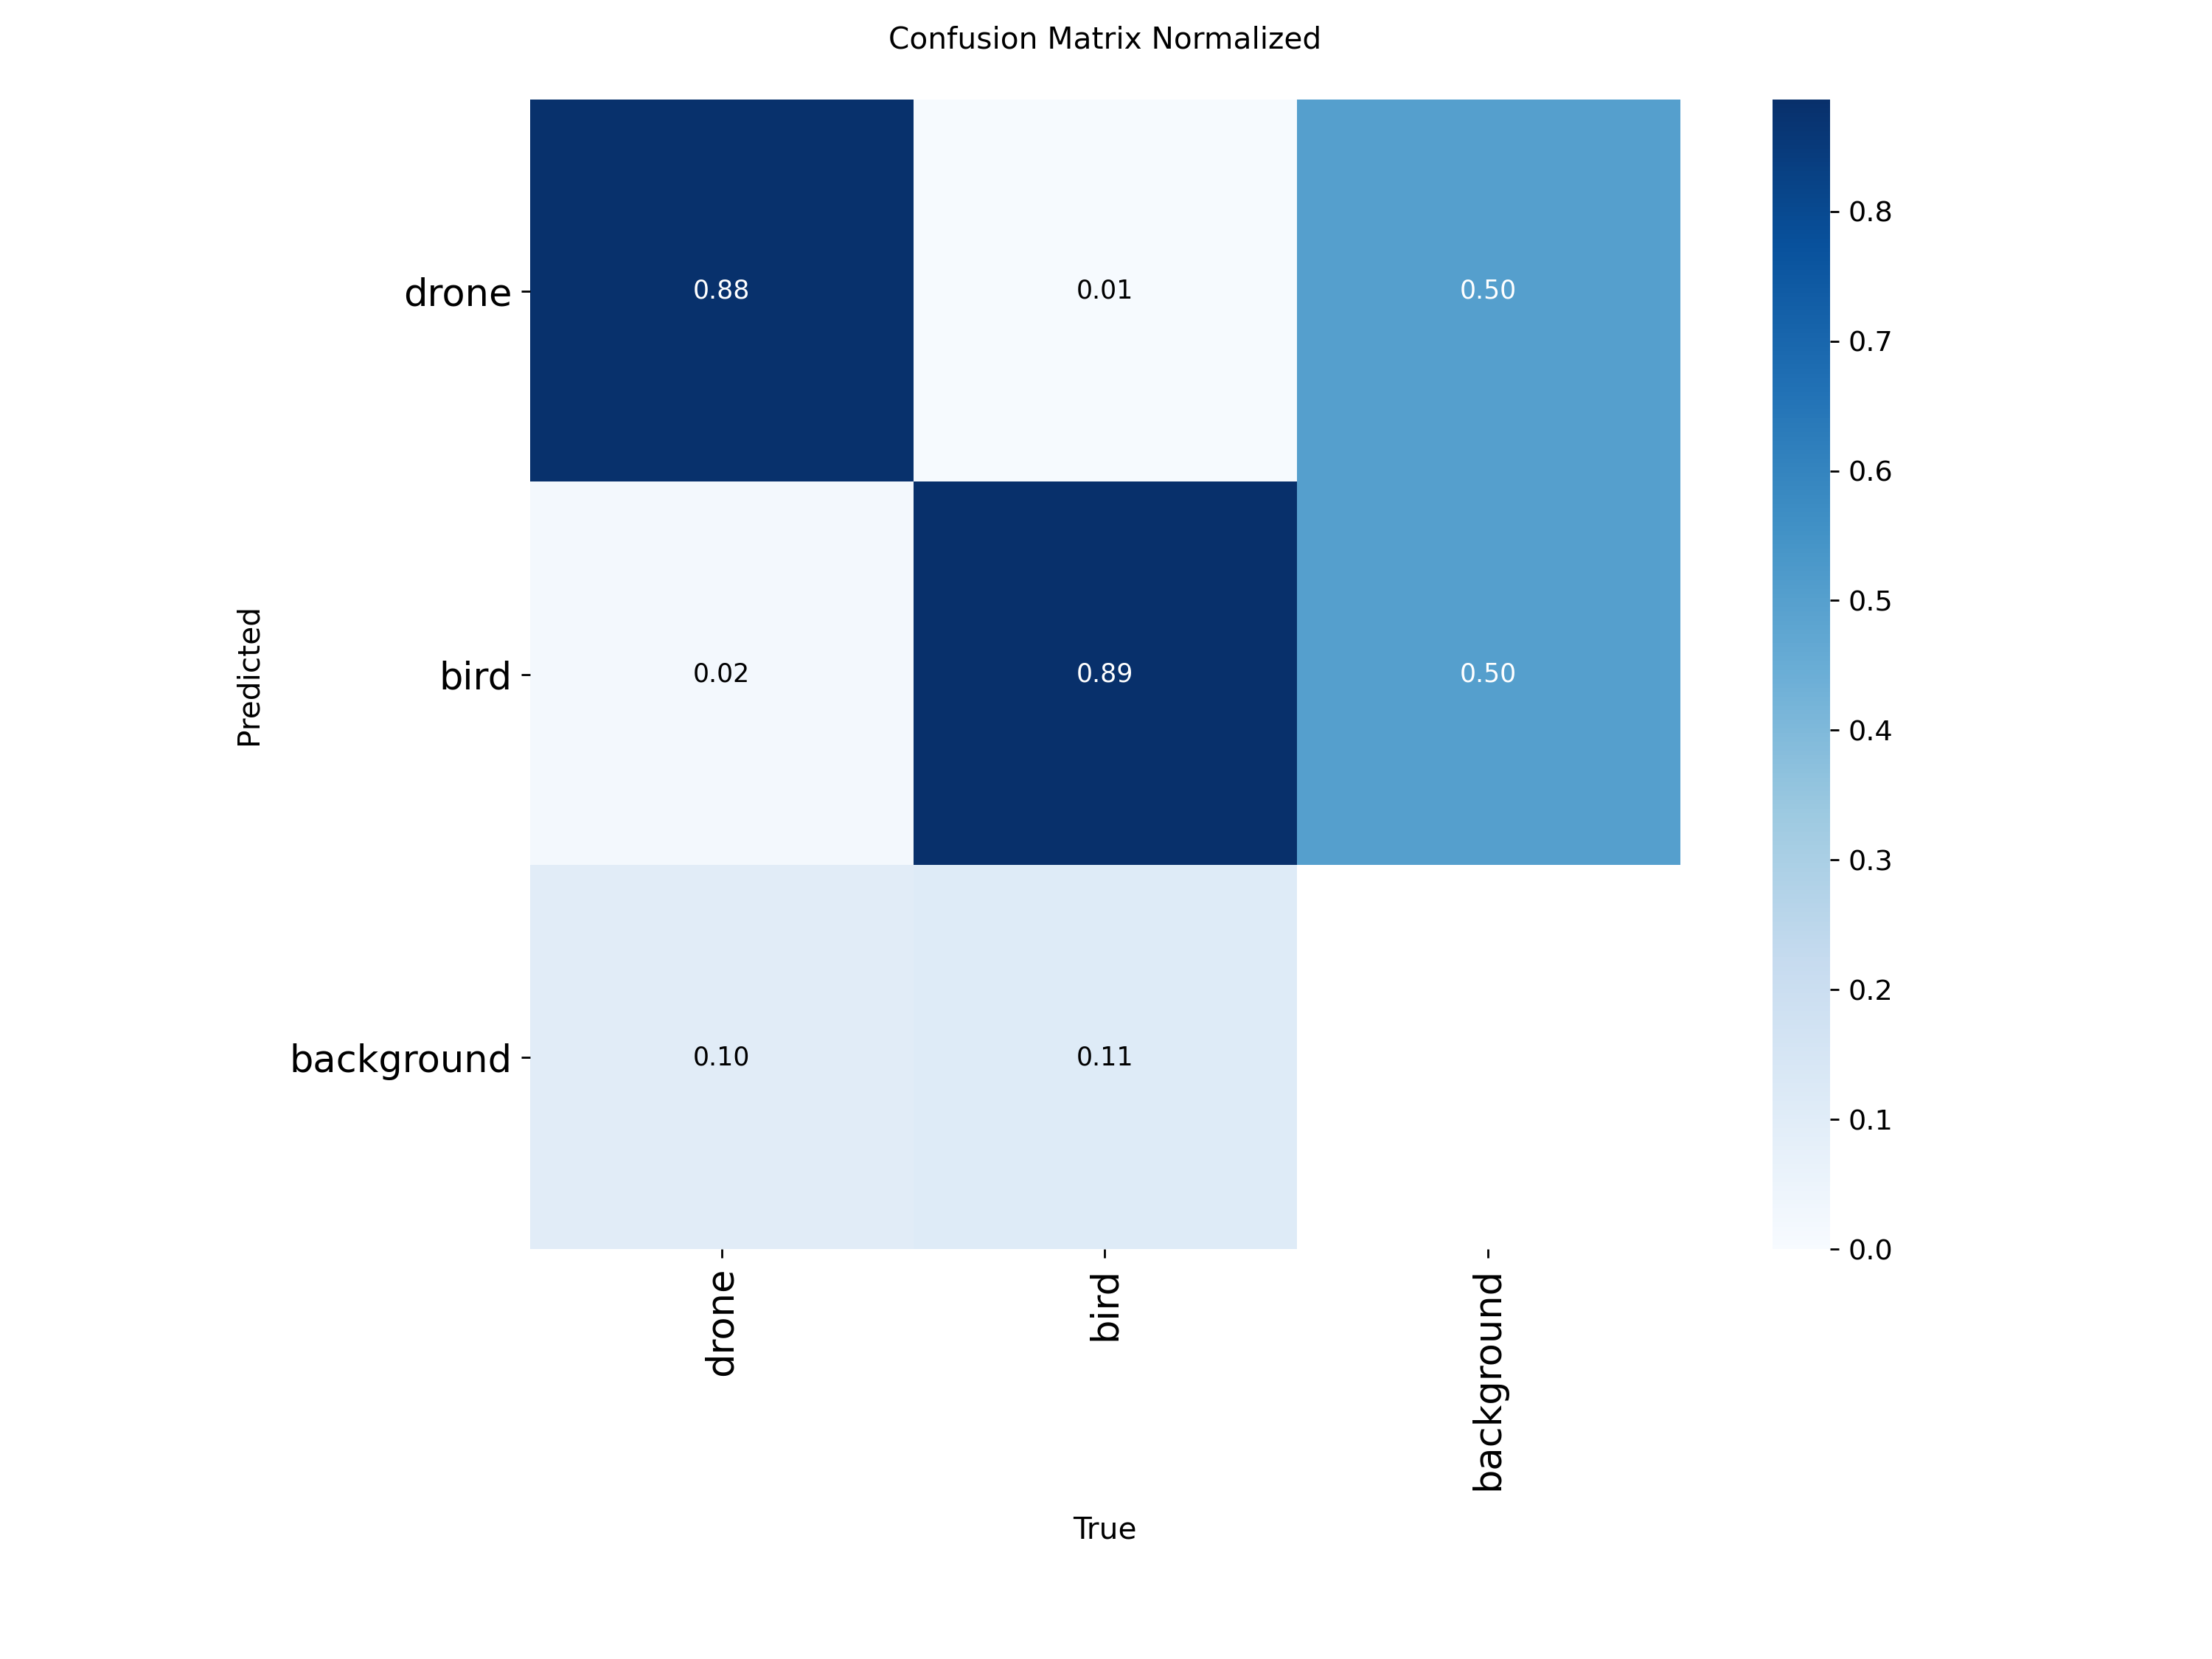

In [19]:
from IPython.display import display, Image
from pathlib import Path

RESULTS_DIR = Path(
    "/content/drive/MyDrive/"
    "DUALITY-AI-HACKATHON/final_validation_results"
)

important_plots = [
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
]

for plot_name in important_plots:
    plot_path = RESULTS_DIR / plot_name

    if plot_path.exists():
        print(f"\n===== {plot_name} =====")
        display(Image(filename=str(plot_path), width=800))

### Confusion Matrix Analysis

The normalized confusion matrix demonstrates strong class-level discrimination between drones and birds.

- Approximately **88% of true drone instances** were correctly identified as drones.
- Approximately **89% of true bird instances** were correctly identified as birds.
- Direct cross-class confusion was low, with only approximately **2% drone-to-bird confusion** and **1% bird-to-drone confusion**.

This indicates that including birds as a dedicated negative/clutter class helped the model distinguish drones from visually similar airborne objects. The background entries represent unmatched predictions and missed detections within the object-detection evaluation process and are not an additional trained object class.

Overall, the confusion matrix supports the quantitative evaluation results, demonstrating strong discrimination between the two target classes while leaving room for improvement in detecting difficult, small, or low-visibility targets.

## Final Model Evaluation

The previously trained YOLO11n model was loaded from the saved `final_eo_model.pt` weights and independently evaluated in Google Colab using an NVIDIA Tesla T4 GPU.

The evaluation was performed on the held-out validation set containing 441 images and 766 annotated object instances.

### Final Validation Metrics

| Metric | Score |
|---|---:|
| Precision | 0.9445 |
| Recall | 0.8558 |
| mAP@0.50 | 0.9053 |
| mAP@0.50–0.95 | 0.6473 |

The model achieved an mAP@0.50 of approximately **90.53%**, demonstrating strong overall detection performance for the drone and bird classes.

Minor differences compared with the original local validation run are expected because the model was re-evaluated using a different hardware backend and software environment.

## Performance Curve Analysis

To further evaluate the trained YOLO11n model, Precision–Recall and F1-confidence curves were analyzed.

The Precision–Recall curve illustrates the trade-off between precision and recall across different confidence thresholds, while the F1-confidence curve helps identify a suitable operating confidence threshold by balancing precision and recall.

In [23]:
from ultralytics import YOLO
from pathlib import Path

MODEL_PATH = "/content/drive/MyDrive/DUALITY-AI-HACKATHON/models/final_eo_model.pt"

YAML_PATH = Path(
    "/content/duality_dataset/datasets/combined_eo_v2/data_colab.yaml"
)

model = YOLO(MODEL_PATH)

metrics = model.val(
    data=str(YAML_PATH),
    imgsz=512,
    batch=16,
    device=0,
    plots=True,
    project="/content/drive/MyDrive/DUALITY-AI-HACKATHON",
    name="final_validation_results",
    exist_ok=True
)

print("\n✅ VALIDATION COMPLETE")
print("Results saved directly to Google Drive:")
print(metrics.save_dir)

print("\n========== FINAL METRICS ==========")
print(f"Precision       : {metrics.box.mp:.4f}")
print(f"Recall          : {metrics.box.mr:.4f}")
print(f"mAP@0.50        : {metrics.box.map50:.4f}")
print(f"mAP@0.50-0.95   : {metrics.box.map:.4f}")

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4028.7±896.5 MB/s, size: 962.1 KB)
val: Scanning /content/duality_dataset/datasets/combined_eo_v2/val/labels.cache... 441 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 441/441 115.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 4.4it/s 6.4s
                   all        441        766      0.945      0.856      0.905      0.647
                 drone        441        441      0.949      0.841      0.913       0.66
                  bird        325        325       0.94      0.871      0.897      0.635
Speed: 1.5ms preprocess, 2.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/drive/MyDrive/DUALITY-AI-HACKATHON/final_validation_results

✅ VALIDATION COMPLETE
R

In [24]:
from pathlib import Path

RESULTS_DIR = Path(
    "/content/drive/MyDrive/DUALITY-AI-HACKATHON/final_validation_results"
)

print("========== SAVED RESULT FILES ==========")

for file in sorted(RESULTS_DIR.iterdir()):
    print(file.name)

========== SAVED RESULT FILES ==========
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg



==================== BoxPR_curve.png ====================


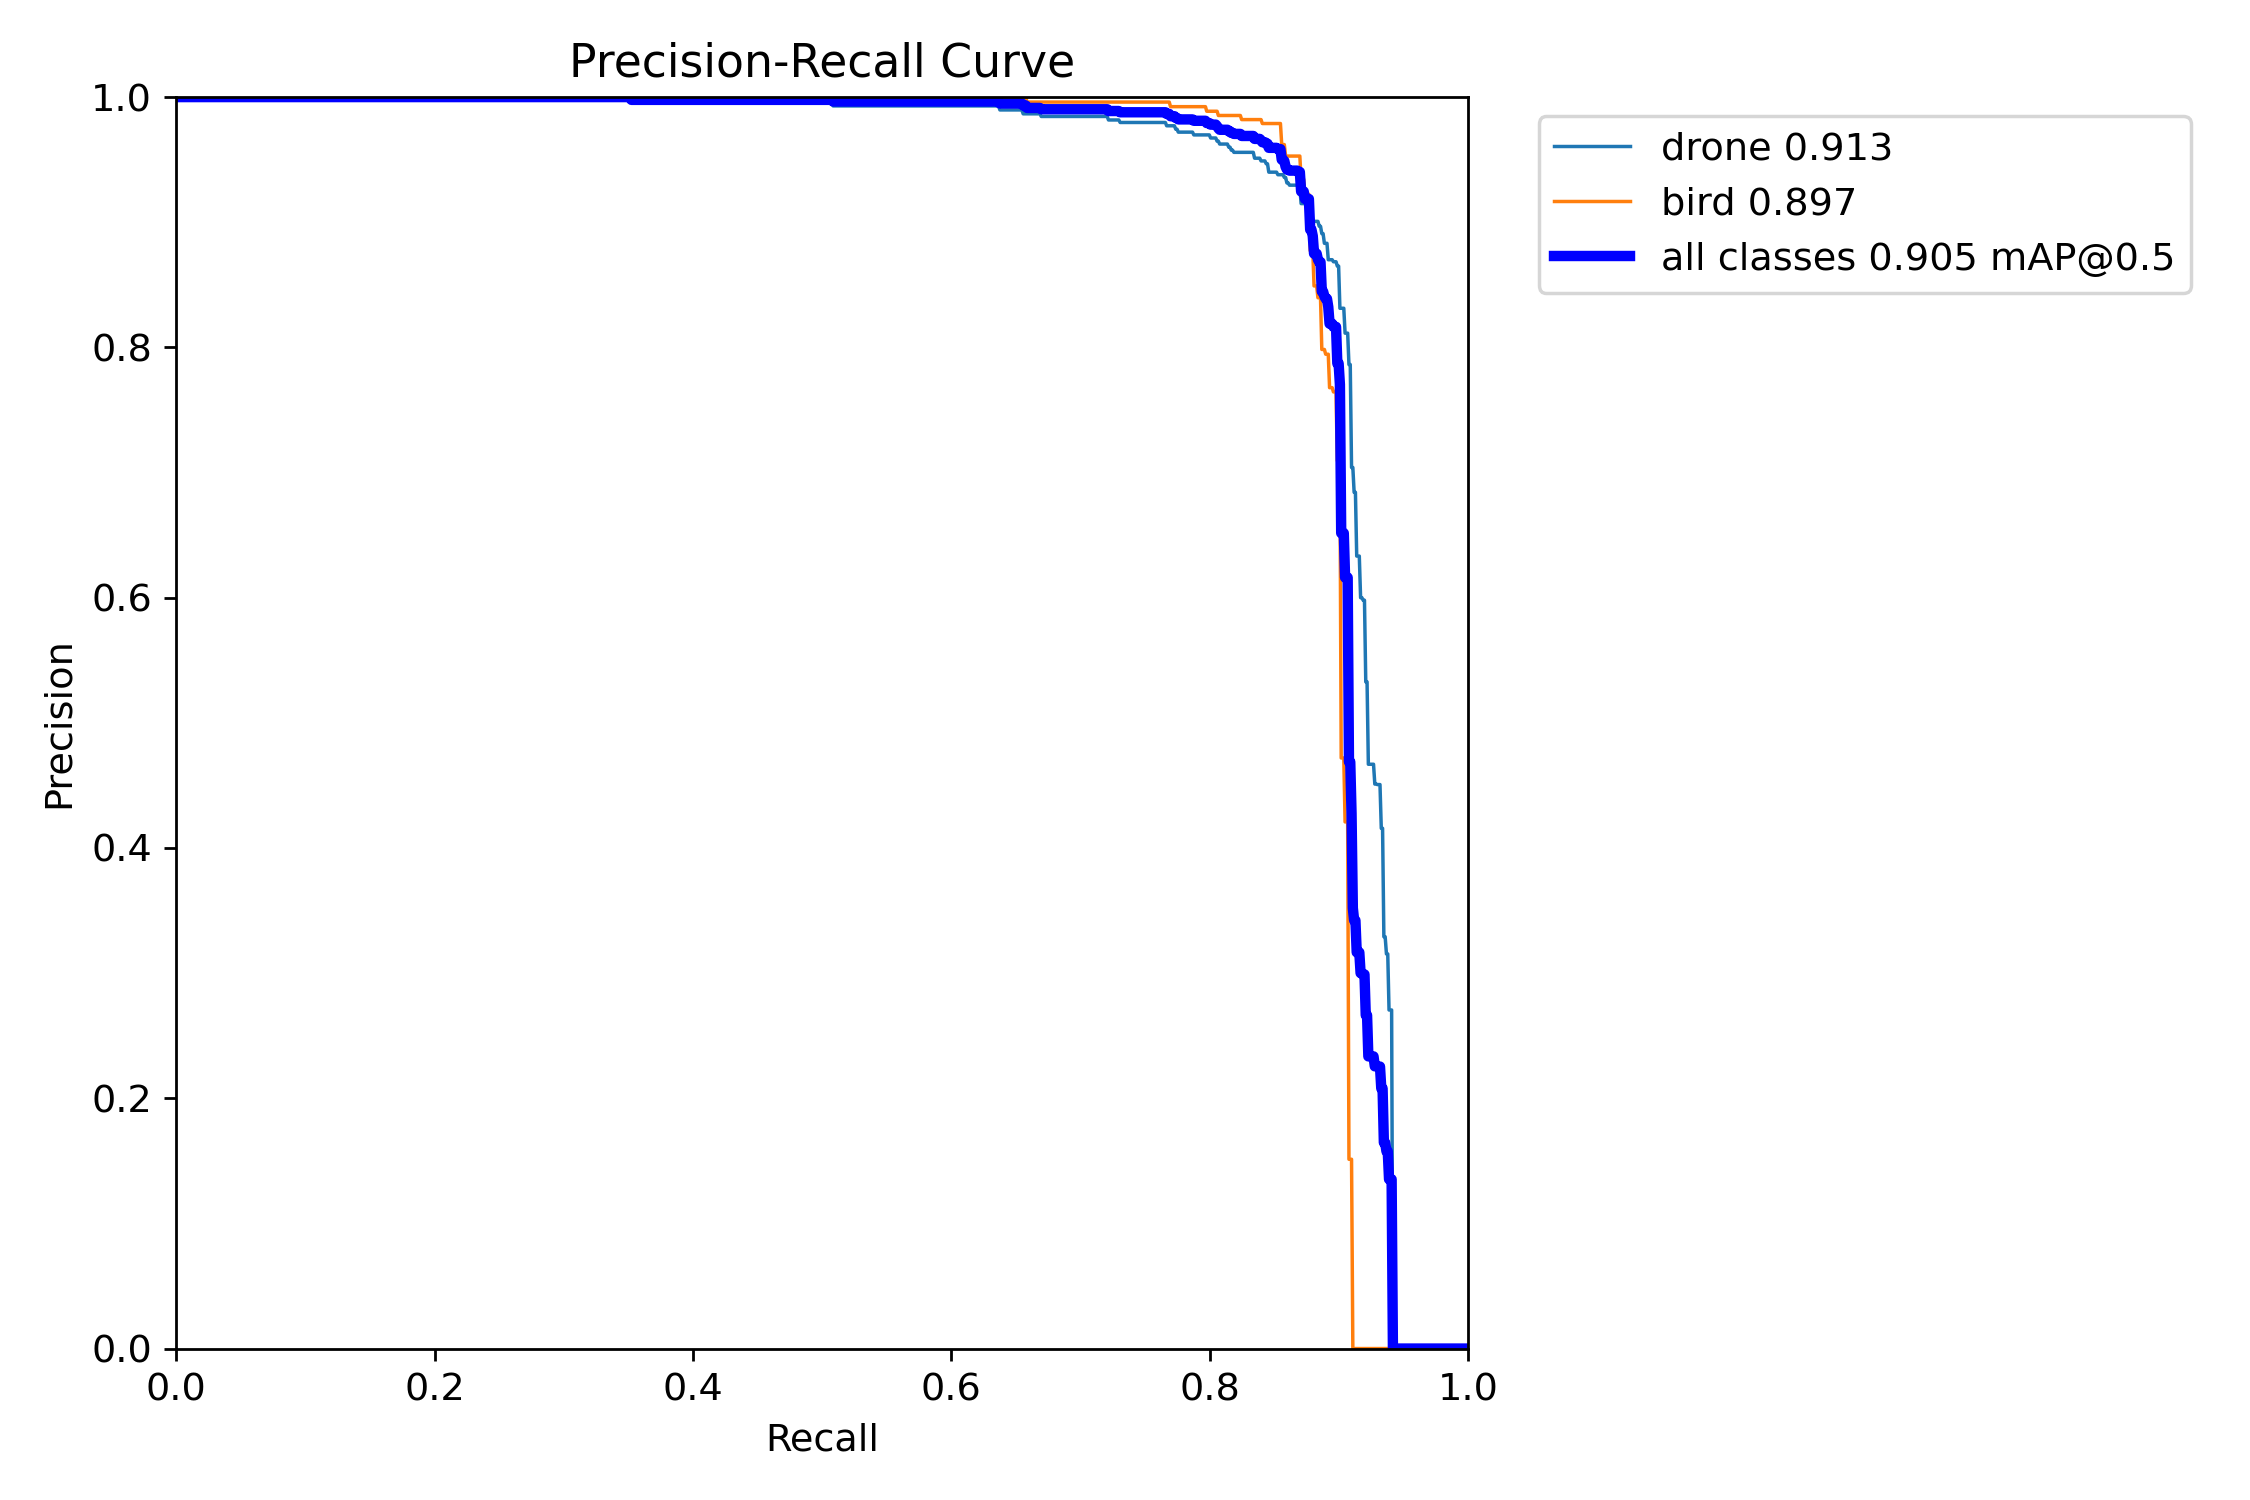


==================== BoxF1_curve.png ====================


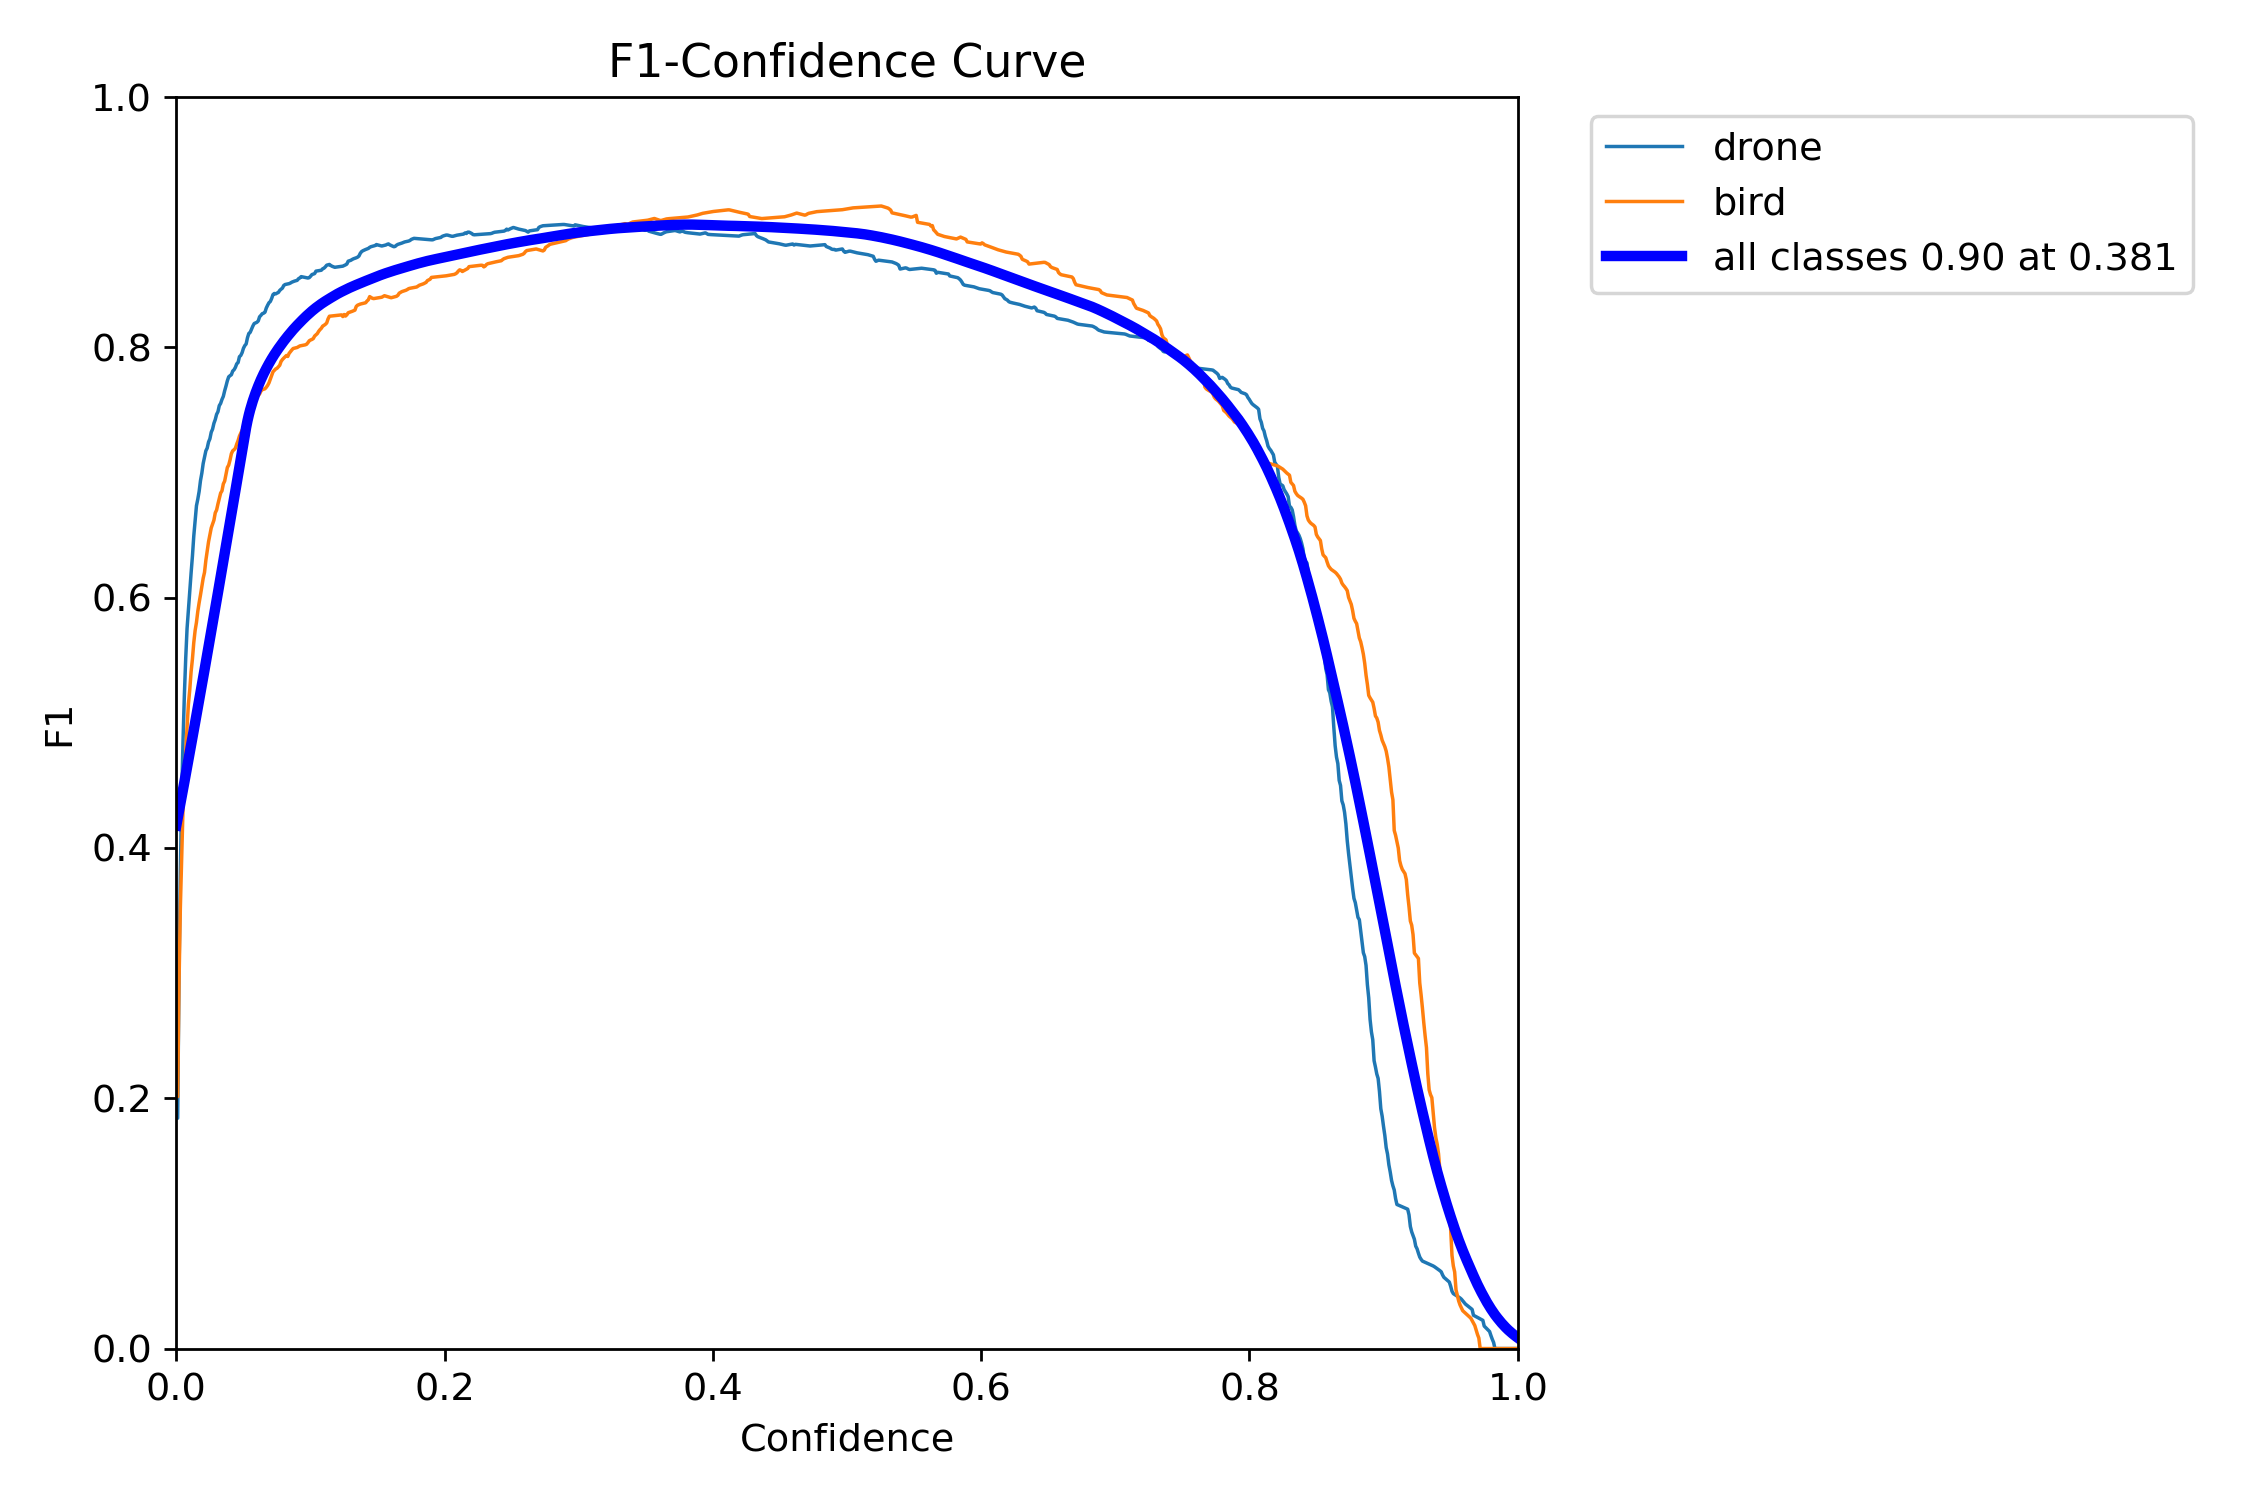

In [29]:
from IPython.display import display, Image
from pathlib import Path

RESULTS_DIR = Path(
    "/content/drive/MyDrive/DUALITY-AI-HACKATHON/final_validation_results"
)

plots = [

    "BoxPR_curve.png",
    "BoxF1_curve.png"
]

for plot_name in plots:
    plot_path = RESULTS_DIR / plot_name

    print(f"\n{'='*20} {plot_name} {'='*20}")

    if plot_path.exists():
        display(Image(filename=str(plot_path), width=850))
    else:
        print(f"❌ File not found: {plot_path}")

# 8. Performance Curve Analysis

## Precision–Recall Curve

The Precision–Recall curve evaluates the relationship between precision and recall across different confidence thresholds.

A strong curve indicates that the model maintains useful precision as recall increases.

The observed curve is consistent with the final mAP@0.50 score of **0.9053**.

## F1–Confidence Curve

The F1 score represents the harmonic mean of precision and recall.

The F1-confidence curve helps identify confidence regions where the detector achieves a useful balance between:

- Avoiding false detections.
- Maintaining sufficient detection coverage.

The optimal deployment threshold may vary depending on the application.

For a safety-oriented drone-detection system, a lower threshold may improve recall but increase false positives. A higher threshold may reduce false positives while increasing the risk of missed targets.

# 9. Qualitative Validation Analysis

Quantitative metrics provide an overall measure of model performance, but visual inspection is also important for understanding detector behaviour.

The following examples compare:

- Ground-truth annotations.
- Predictions generated by the final YOLO11n model.

The qualitative evaluation examines the model's ability to handle:

- Different target scales.
- Drone and bird discrimination.
- Multiple objects.
- Complex backgrounds.
- Small distant targets.


===== val_batch0_labels.jpg =====


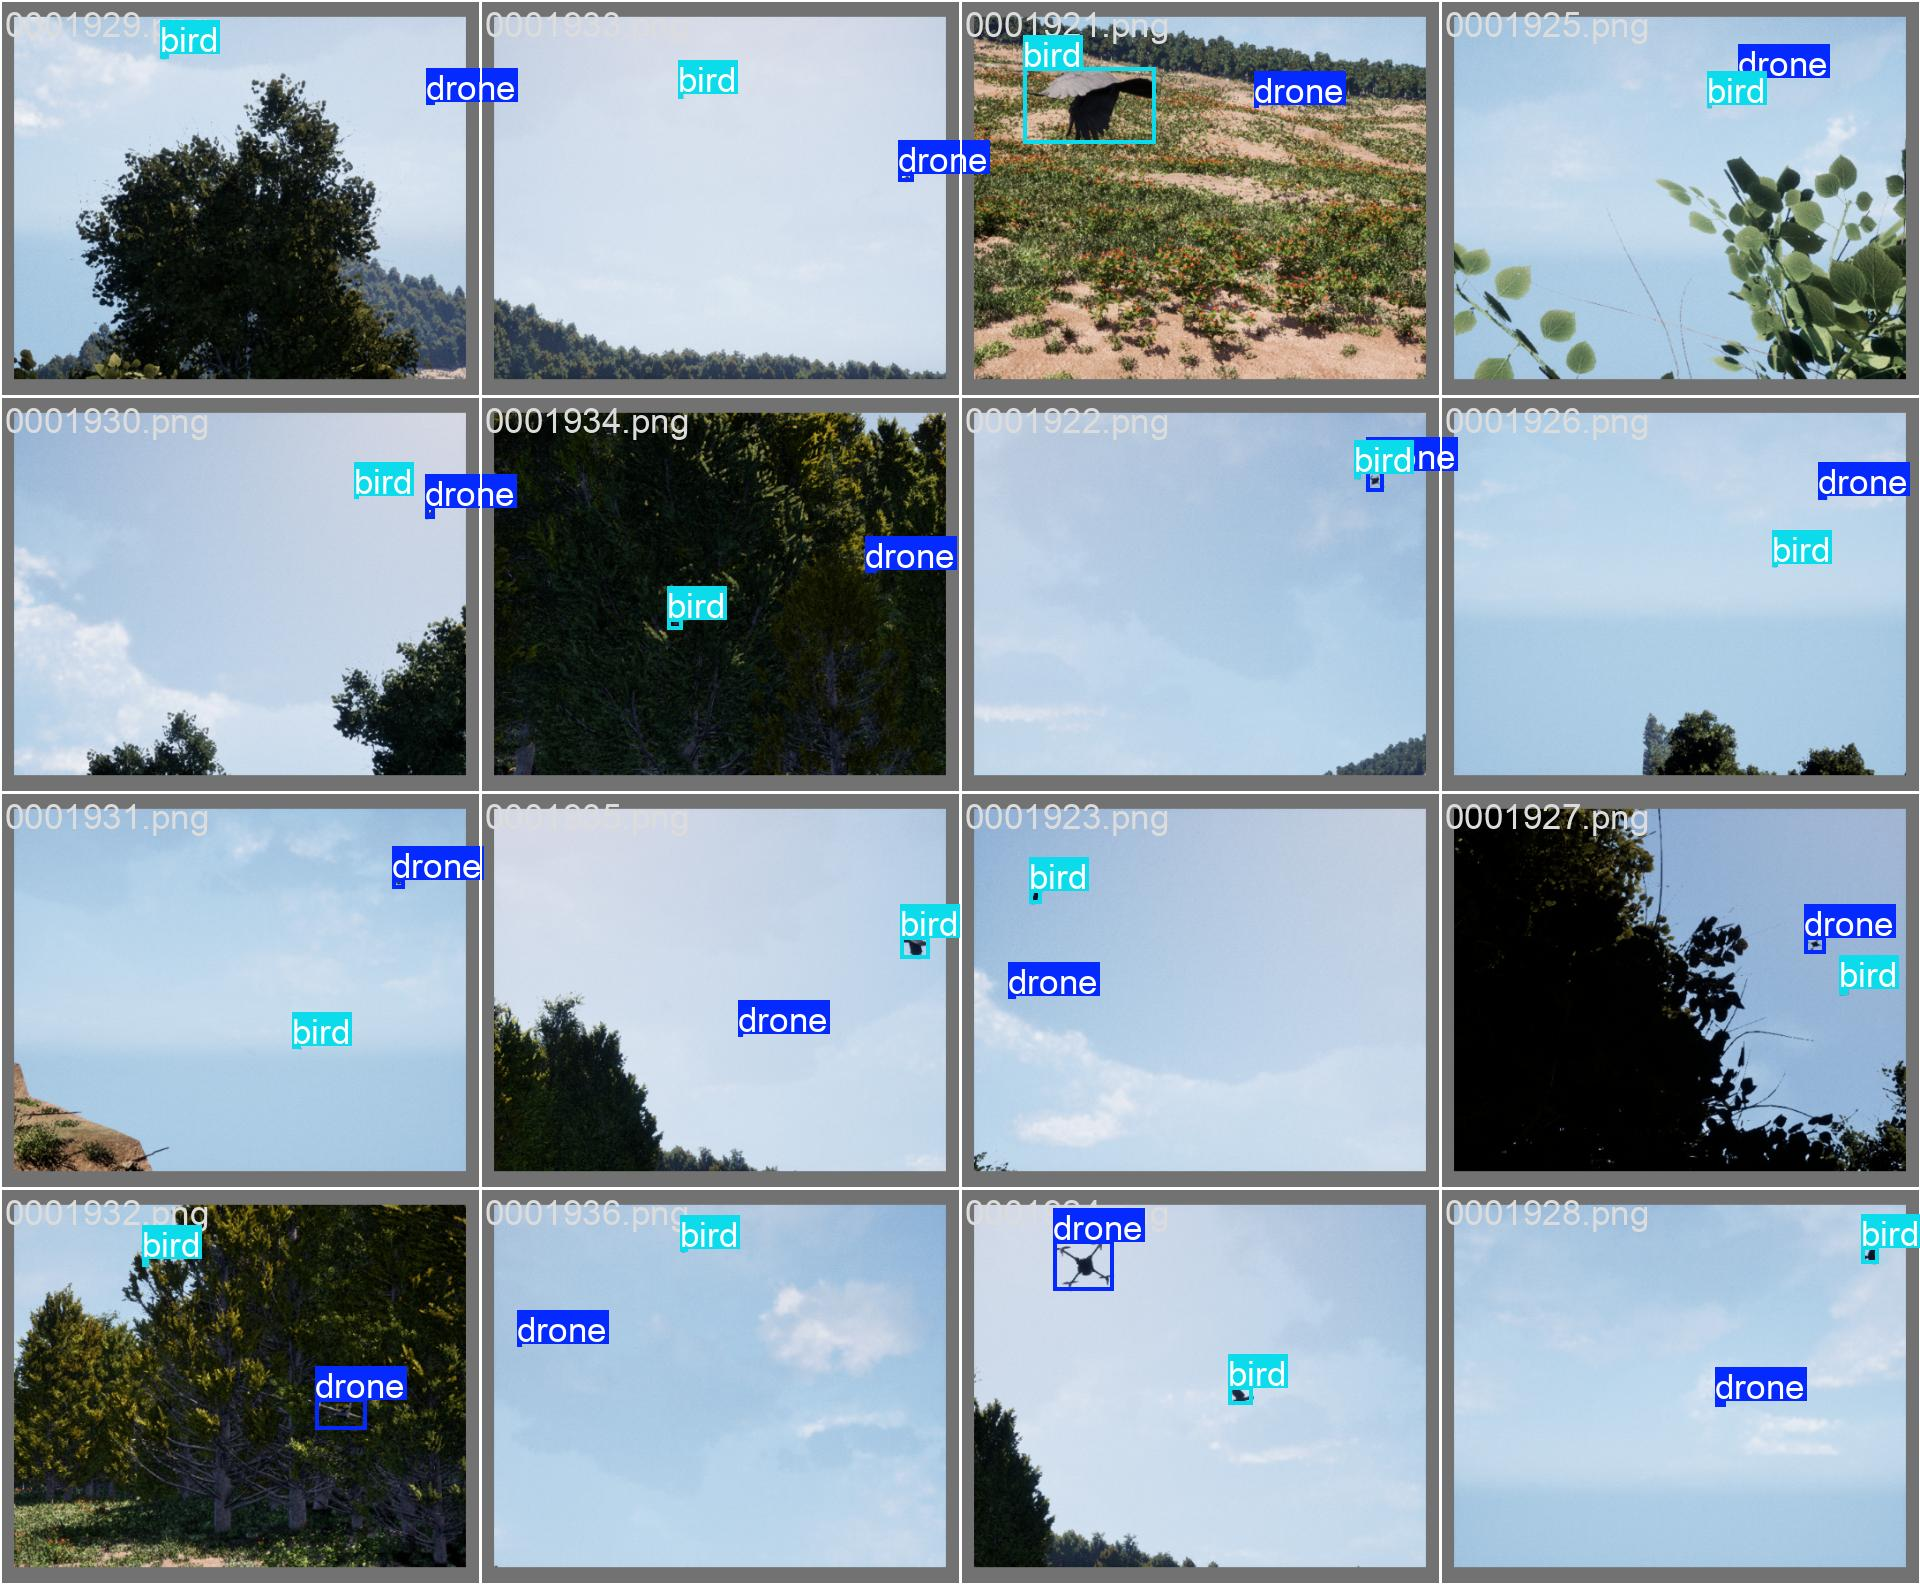


===== val_batch0_pred.jpg =====


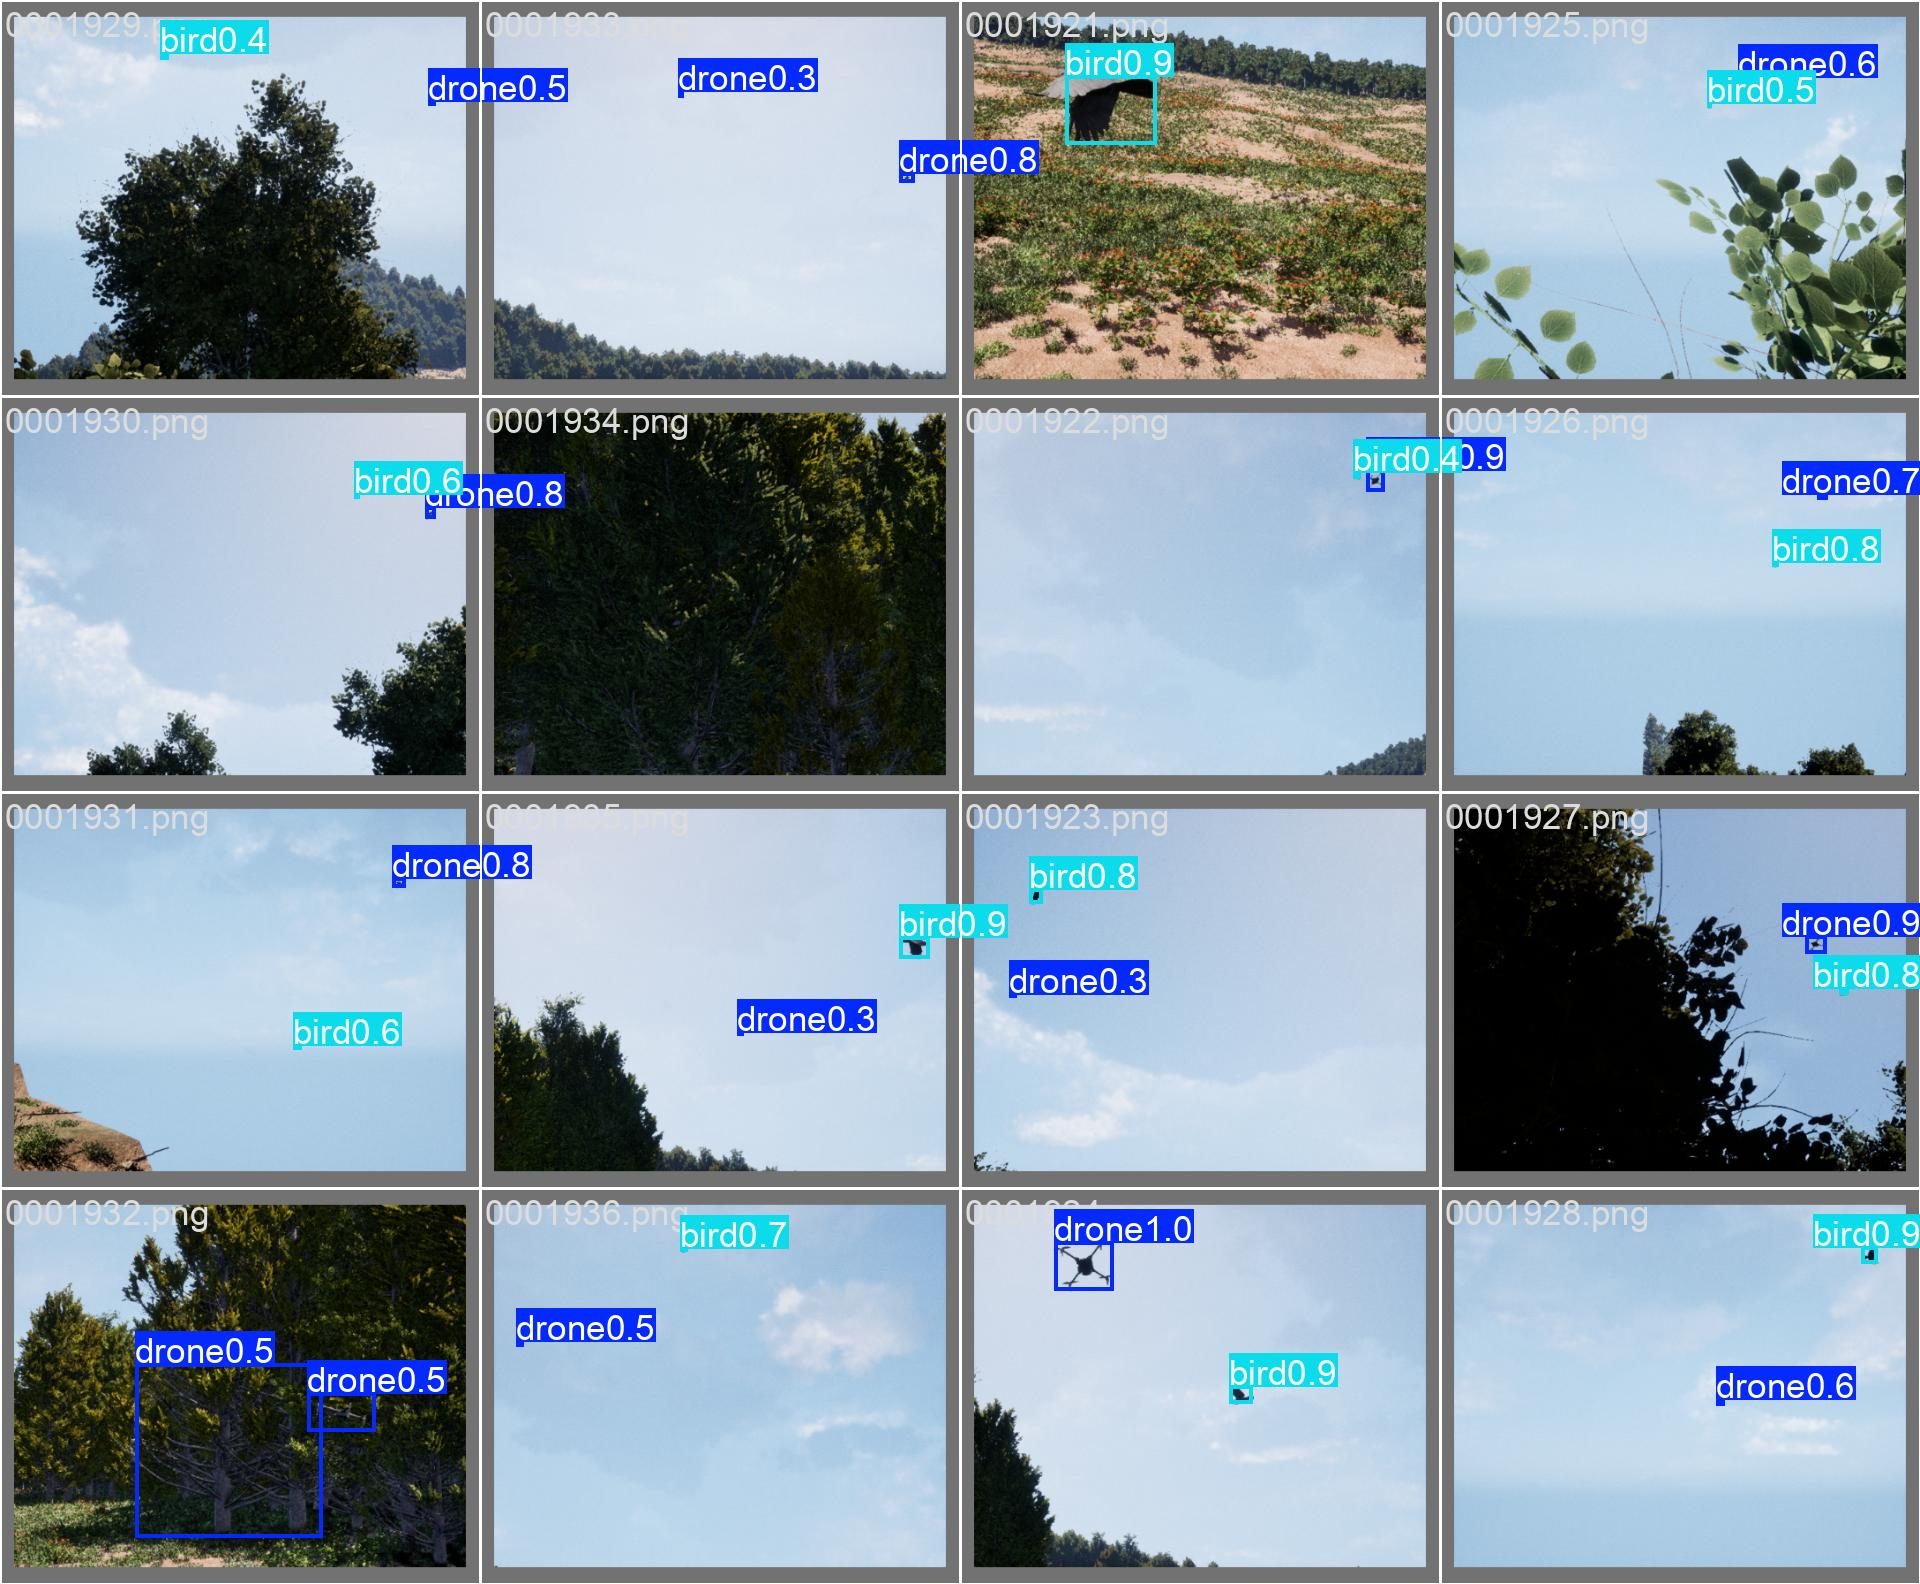


===== val_batch1_labels.jpg =====


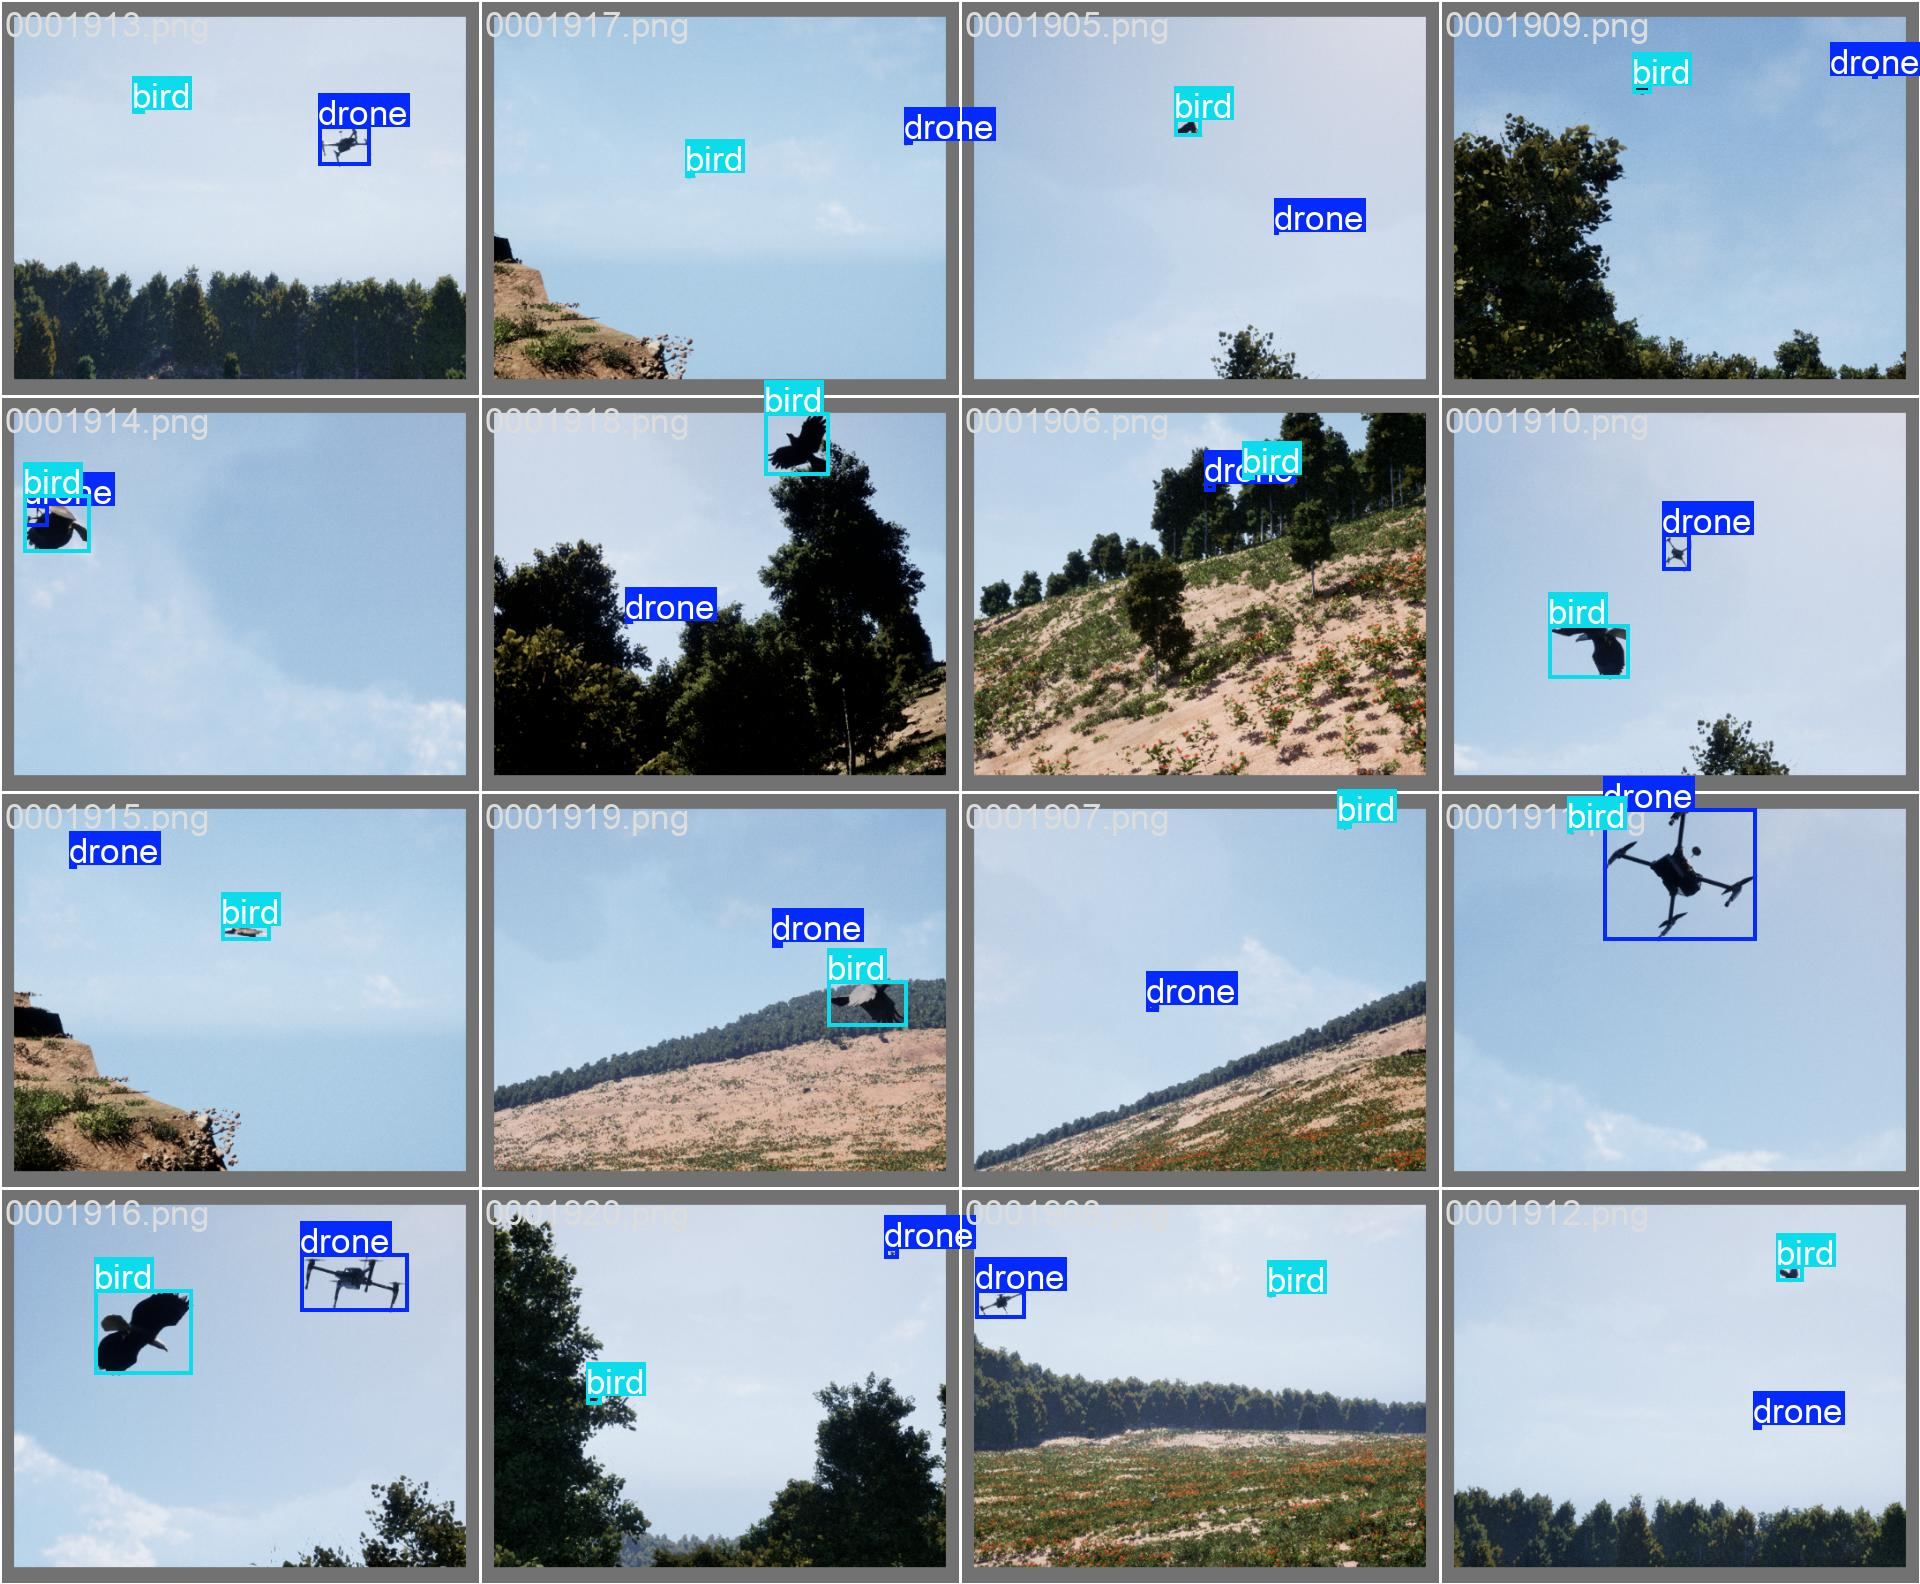


===== val_batch1_pred.jpg =====


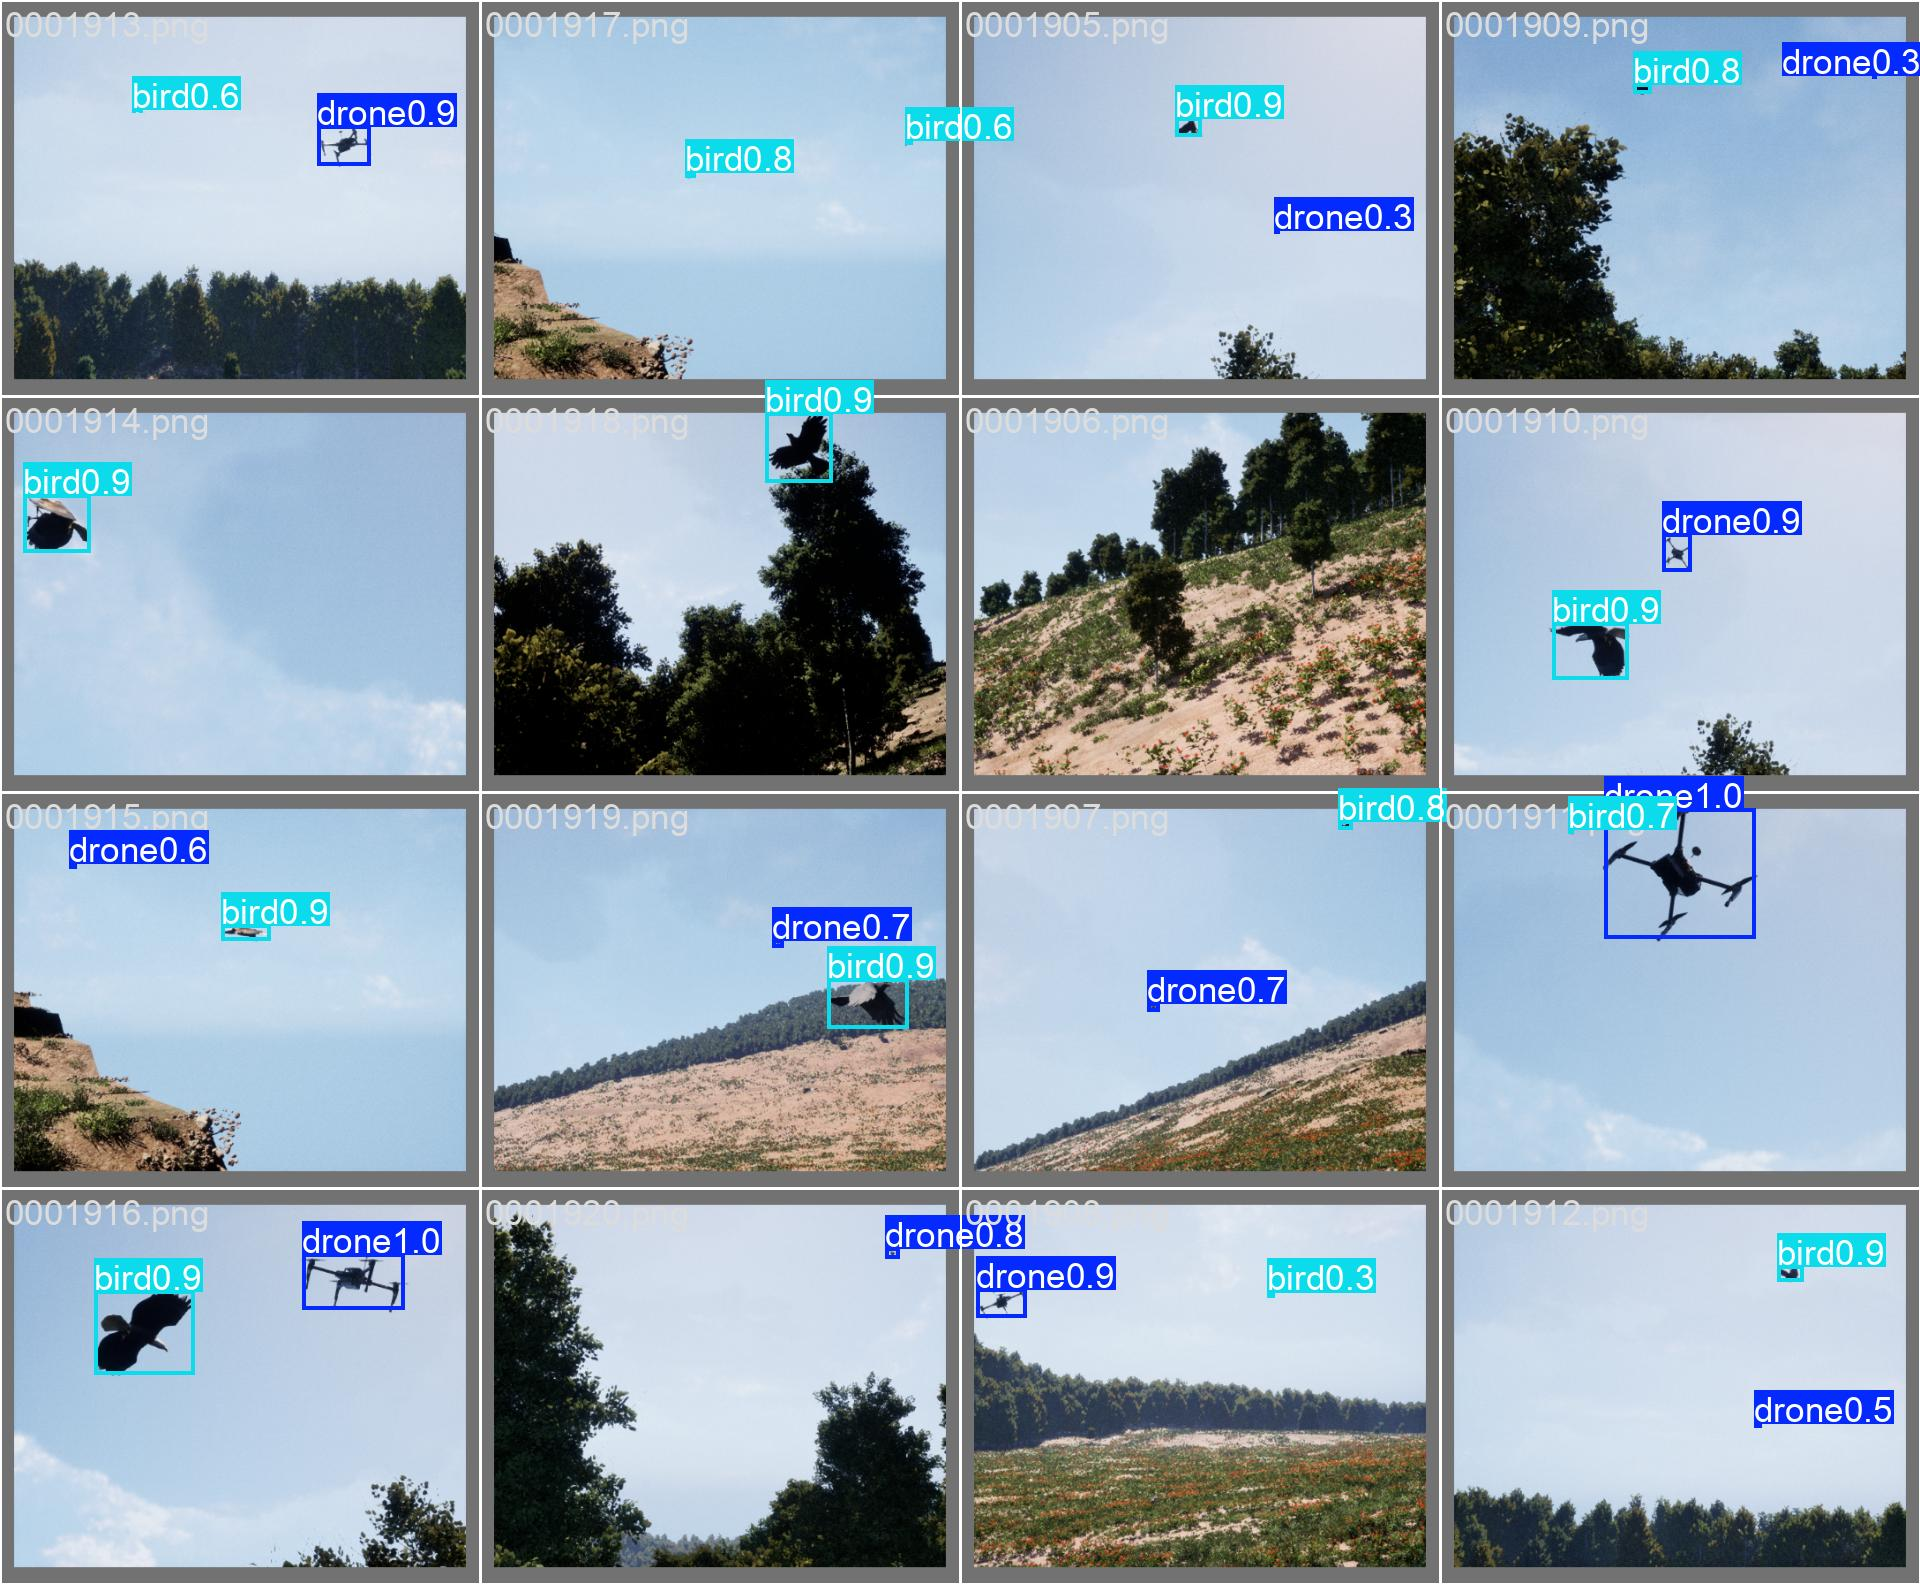

In [26]:
from IPython.display import display, Image
from pathlib import Path

RESULTS_DIR = Path(
    "/content/drive/MyDrive/DUALITY-AI-HACKATHON/final_validation_results"
)

comparison_images = [
    "val_batch0_labels.jpg",
    "val_batch0_pred.jpg",
    "val_batch1_labels.jpg",
    "val_batch1_pred.jpg",
]

for image_name in comparison_images:
    image_path = RESULTS_DIR / image_name

    print(f"\n===== {image_name} =====")

    if image_path.exists():
        display(Image(filename=str(image_path), width=900))

# 10. Cross-Environment Validation

The same saved model was evaluated in two different computational environments.

| Metric | Local Apple M5/MPS | Google Colab/Tesla T4 |
|---|---:|---:|
| Precision | 0.948 | 0.9445 |
| Recall | 0.857 | 0.8558 |
| mAP@0.50 | 0.905 | 0.9053 |
| mAP@0.50–0.95 | 0.649 | 0.6473 |

The results remained highly consistent across both environments.

This provides additional evidence that the final performance is associated with the saved model artifact rather than a single runtime environment.

# 11. Limitations

Although the final model achieved strong validation performance, several limitations remain.

## 1. Synthetic-to-Real Domain Gap

Synthetic imagery may not perfectly reproduce all characteristics of real EO sensors and real-world environments.

## 2. Small Object Detection

Extremely distant drones and birds may occupy very few pixels, making reliable detection difficult.

## 3. Dataset Scale

The final dataset contains 1,962 images. A larger and more diverse dataset could improve generalization.

## 4. Limited Independent Real-World Ground Truth

The primary quantitative evaluation was performed on the held-out validation split. A larger independently annotated real-world test dataset would provide stronger evidence of real-world generalization.

## 5. Environmental Diversity

Additional variation in weather, illumination, sensor noise, target orientation, and background conditions could further improve robustness.

# 12. Future Work

Future improvements could include:

1. Generating additional Falcon scenarios with greater environmental diversity.
2. Expanding the pixels-on-target distribution.
3. Introducing additional aerial confuser classes.
4. Evaluating on a larger independently annotated real-world dataset.
5. Exploring synthetic-to-real domain adaptation.
6. Performing systematic confidence-threshold optimization.
7. Evaluating larger YOLO variants when additional compute is available.
8. Exporting the final model to ONNX or other optimized deployment formats.
9. Benchmarking inference latency on edge hardware.
10. Investigating temporal information for video-based drone tracking.

# 13. Conclusion

This project demonstrates an end-to-end simulation-driven workflow for EO drone detection using Duality AI Falcon and YOLO11n.

The project included:

- Synthetic EO data generation.
- Custom target-scale distribution configuration.
- Drone and bird class preparation.
- Dataset integration and verification.
- YOLO11n model training.
- Independent model validation.
- Quantitative metric analysis.
- Confusion-matrix analysis.
- Precision–Recall and F1 analysis.
- Qualitative comparison of ground truth and predictions.

The final model achieved:

- **Precision: 94.45%**
- **Recall: 85.58%**
- **mAP@0.50: 90.53%**
- **mAP@0.50–0.95: 64.73%**

The final YOLO11n model is approximately **5.19 MB**, demonstrating a strong balance between detection performance and model efficiency.

The results support the value of simulation-driven synthetic data generation for developing aerial object-detection systems, while also highlighting the importance of continued evaluation on independently annotated real-world data.